# Auditoría estructural de TLM:UAV

**Objetivo.** Determinar qué representan realmente los archivos locales antes de definir features, particiones o modelos.

Esta auditoría no entrena clasificadores. Examina procedencia, esquemas, labels, dependencia temporal, composición de vuelos y trazabilidad de `Fusion_Data.csv`. Las advertencias previas se tratan como hipótesis: solo se aceptan cuando pueden reproducirse con los datos o con una fuente primaria.

## Preguntas de auditoría

1. ¿Cuántos archivos, esquemas y targets contiene la copia local?
2. ¿Las filas forman observaciones independientes o secuencias temporales?
3. ¿Los archivos `Random` y `AddNum` representan barajado, combinación de vuelos o aumento sintético?
4. ¿Las etiquetas concuerdan entre sensores?
5. ¿Puede reconstruirse la tabla fusionada desde sus fuentes?
6. ¿Qué contaminación introduce un split aleatorio por filas?
7. ¿Qué protocolo es defendible con las unidades independientes disponibles?

## Importaciones y configuración

La raíz se resuelve desde el directorio actual. Ejecutar el cuaderno desde otra carpeta detiene la auditoría en lugar de buscar rutas personales o silenciosamente usar otro dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.audit import (
    ATT_FILE,
    CLASS_NAMES,
    FUSION_FILE,
    plot_class_distribution,
    plot_label_timeline,
    run_full_audit,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "dataset").is_dir() or not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("Ejecute este cuaderno desde la raíz del proyecto TLM.")

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)

audit = run_full_audit(PROJECT_ROOT)

## Procedencia y clases

La [ficha de Kaggle](https://www.kaggle.com/datasets/luyucwnu/tlmuav-anomaly-detection-datasets) atribuye el dataset a simulación software-in-the-loop. Define 0 como normal, 1 como falla GPS, 2 como falla del acelerómetro, 3 como falla de motor y 4 como falla RC.

El artículo de [Time Line Modeling](https://doi.org/10.3390/app13074301) describe anclaje y ampliación de ventanas de falla. El trabajo de [fusión multisensor](https://doi.org/10.1016/j.engappai.2024.107961) presenta MHSIA. Estas referencias explican la intención; las tablas siguientes verifican la copia local de manera independiente.

In [2]:
class_reference = pd.DataFrame(
    {
        "label": range(5),
        "class_name": CLASS_NAMES,
    }
)
display(class_reference)

,label,class_name
0,0,Normal
1,1,GPS fault
2,2,Accelerometer fault
3,3,Engine fault
4,4,RC fault


## Integridad de la instantánea

Las verificaciones son aserciones ejecutables. El manifiesto SHA-256 se calcula antes y después de la auditoría, de modo que una modificación accidental de los CSV provoca un error.

In [3]:
display(audit.checks.to_frame())

,passed
dataset_manifest_unchanged,True
seventeen_csv_files_loaded,True
all_files_have_valid_labels,True
no_missing_cells,True
fusion_shape_is_12253_by_19,True
fusion_timestamp_is_monotonic,True
fusion_interpolation_reproduced,True
fusion_duplicate_pairs_confirmed,True
two_gps_flights_recovered,True
raw_label_agreement_above_99_percent,True


## Inventario de archivos

Una tabla con labels no implica que todas sus filas pertenezcan a la misma secuencia. Por eso se inspeccionan por separado el orden temporal, los timestamps duplicados y los conflictos de target bajo un mismo reloj.

In [4]:
inventory_view = audit.inventory.assign(
    sha256=lambda table: table["sha256"].str[:16]
)[
    [
        "file",
        "rows",
        "columns",
        "missing_cells",
        "label_column",
        "time_column",
        "time_is_monotonic",
        "duplicate_timestamps",
        "timestamp_label_conflicts",
        "sha256",
    ]
]
display(inventory_view)

,file,rows,columns,missing_cells,label_column,time_column,time_is_monotonic,duplicate_timestamps,timestamp_label_conflicts,sha256
0,ATT/ALL_FAIL_LOG_ATT.csv,4900,12,0,lables,TimeUS,True,0,0,ac80afd4c8f5f7c7
1,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,4319,17,0,labels,TimeUS,False,1834,783,284b721e9940297e
2,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,21597,17,0,labels,abTimeUS,False,9171,3915,09774d00b923d3a7
3,AddNum/ALL_FAIL_LOG_RATE_Add_Random.csv,8638,15,0,labels,TimeUS,False,3668,1575,8118b3e1124f58db
4,AddNum/ALL_FAIL_LOG_VIBE_0_Add_Random.csv,8638,8,0,labels,TimeUS,False,3668,1569,61945043e4af71ea
5,BARO/ALL_FAIL_LOG_BARO.csv,4900,11,0,labels,TimeUS,True,0,0,3658fa3b6e86b32e
6,BAT/ALL_FAIL_LOG_BAT_0.csv,4900,12,0,labels,TimeUS,True,0,0,5da78abbc688fbef
7,CTUN/ALL_FAIL_LOG_CTUN.csv,4900,15,0,labels,TimeUS,True,0,0,11a744c7598c0748
8,Fusion_Data.csv,12253,19,0,labels,timestamp,True,4084,0,e17dc97292bbf32f
9,GPS/ALL_FAIL_LOG_GPS_0.csv,2450,17,0,labels,TimeUS,True,0,0,6e11c4dde64a9480


## Esquema y distribución del target

Los nombres `labels` y `lables` se reconocen, pero no se corrigen dentro de los archivos originales. Las constantes y duplicaciones se auditan por fuente; eliminarlas será responsabilidad de un transformador ajustado con train.

In [5]:
constant_columns = audit.schema.loc[audit.schema["constant"]]
nonconstant_duplicates = audit.duplicate_columns.loc[
    audit.duplicate_columns["nonconstant"]
]
fusion_distribution = audit.class_distribution.loc[
    audit.class_distribution["file"] == FUSION_FILE,
    ["label", "class_name", "count", "fraction"],
]

display(constant_columns.reset_index(drop=True))
display(nonconstant_duplicates.reset_index(drop=True))
display(fusion_distribution.reset_index(drop=True))

,file,column,dtype,non_null,unique,constant
0,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,I,int64,4319,1,True
1,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,HDop,float64,4319,1,True
2,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,Yaw,int64,4319,1,True
3,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,U,int64,4319,1,True
4,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,abI,int64,21597,1,True
5,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,abEG,int64,21597,1,True
6,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,abEA,int64,21597,1,True
7,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,abGH,int64,21597,1,True
8,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,abAH,int64,21597,1,True
9,AddNum/ALL_FAIL_LOG_VIBE_0_Add_Random.csv,IMU,int64,8638,1,True


,file,left,right,nonconstant
0,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,abGHz,abAHz,True
1,Fusion_Data.csv,ErrRP,ErrYaw,True
2,Fusion_Data.csv,MagY,MagZ,True
3,IMU/ALL_FAIL_LOG_IMU_0_Random.csv,abGHz,abAHz,True
4,MAG/ALL_FAIL_LOG_MAG_0.csv,TimeUS,S,True


,label,class_name,count,fraction
0,0,Normal,6567,0.535950
1,1,GPS fault,1823,0.148780
2,2,Accelerometer fault,1863,0.152044
3,3,Engine fault,1449,0.118257
4,4,RC fault,551,0.044969


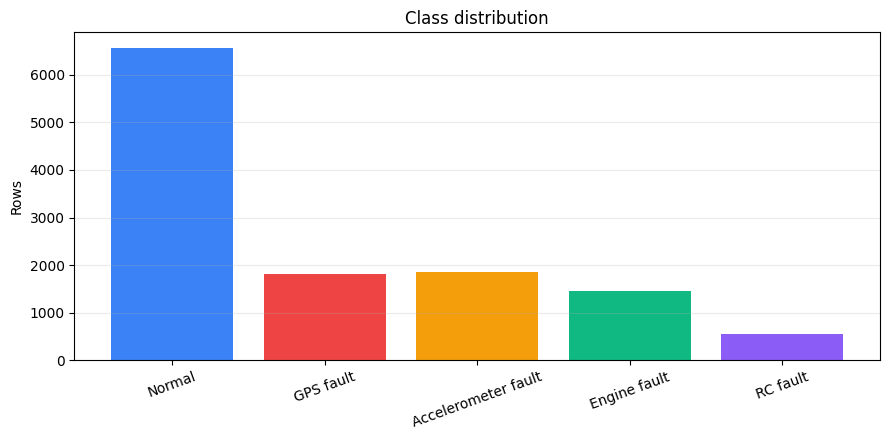

In [6]:
plot_class_distribution(audit.frames[FUSION_FILE])
plt.show()

## Dependencia temporal y episodios

Una fila es un instante dentro de una secuencia. ATT presenta ocho bloques: cuatro intervalos normales alternados con un único episodio de cada falla. Esta estructura impide tratar las 4.900 filas como 4.900 réplicas independientes.

In [7]:
temporal_columns = [
    "file",
    "unique_timestamps",
    "duplicate_timestamps",
    "negative_deltas_in_row_order",
    "median_positive_delta",
    "label_transitions_in_row_order",
    "label_transitions_after_time_sort",
]
display(audit.temporal_summary[temporal_columns])
display(audit.episodes)

,file,unique_timestamps,duplicate_timestamps,negative_deltas_in_row_order,median_positive_delta,label_transitions_in_row_order,label_transitions_after_time_sort
0,ATT/ALL_FAIL_LOG_ATT.csv,4900,0,0,99960.0,7,7
1,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,2485,1834,2193,131399919.0,3101,1568
2,AddNum/ALL_FAIL_LOG_IMU_0_Add_Random.csv,12426,9171,10863,129199966.0,15128,7832
3,AddNum/ALL_FAIL_LOG_RATE_Add_Random.csv,4970,3668,4301,129500262.5,6134,3152
4,AddNum/ALL_FAIL_LOG_VIBE_0_Add_Random.csv,4970,3668,4347,131549859.0,6073,3140
5,BARO/ALL_FAIL_LOG_BARO.csv,4900,0,0,99960.0,7,7
6,BAT/ALL_FAIL_LOG_BAT_0.csv,4900,0,0,99960.0,7,7
7,CTUN/ALL_FAIL_LOG_CTUN.csv,4900,0,0,99960.0,7,7
8,Fusion_Data.csv,8169,4084,0,49980.0,7,7
9,GPS/ALL_FAIL_LOG_GPS_0.csv,2450,0,0,199920.0,7,7


,source,episode,label,class_name,start_row,end_row,rows,start_time,end_time
0,ATT,0,0,Normal,0,757,758,15363852.0,107263744.0
1,ATT,1,1,GPS fault,758,1365,608,107363704.0,168063581.0
2,ATT,2,0,Normal,1366,2097,732,168163541.0,241263456.0
3,ATT,3,2,Accelerometer fault,2098,2716,619,241363416.0,303163686.0
4,ATT,4,0,Normal,2717,3187,471,303263646.0,350264005.0
5,ATT,5,3,Engine fault,3188,3669,482,350363965.0,398463884.0
6,ATT,6,0,Normal,3670,4147,478,398563844.0,446263923.0
7,ATT,7,4,RC fault,4148,4899,752,446363883.0,521463831.0
8,Fusion_Data,0,0,Normal,0,2272,2273,15363852.0,107313724.0
9,Fusion_Data,1,1,GPS fault,2273,4095,1823,107363704.0,168063581.0


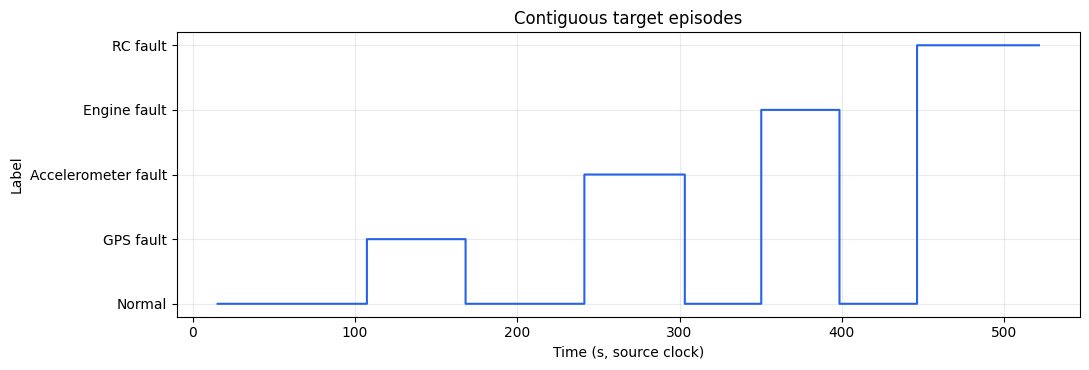

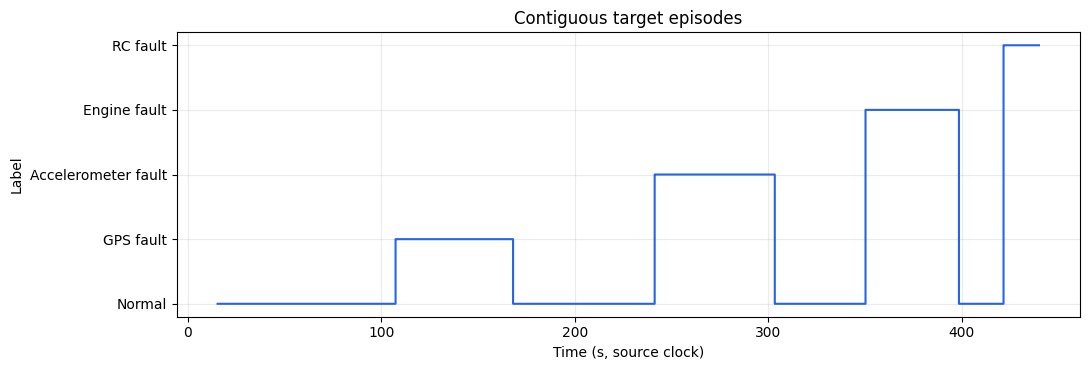

In [8]:
plot_label_timeline(audit.frames[ATT_FILE])
plt.show()

plot_label_timeline(audit.frames[FUSION_FILE])
plt.show()

## Recuperación de vuelos

`TimeUS` es un reloj relativo y se solapa entre registros. GPS conserva semana y milisegundos GPS; al construir tiempo absoluto aparecen dos vuelos separados por aproximadamente 43,2 horas.

Este resultado obliga a usar `(flight_id, TimeUS)` como clave. Ordenar únicamente por `TimeUS` mezclaría estados de vuelos distintos.

In [9]:
display(audit.flight_summary)

,inferred_flight,rows,duration_seconds,gps_week,gps_absolute_start_ms,gps_absolute_end_ms,TimeUS_min,TimeUS_max,label_0,label_1,label_2,label_3,label_4
0,0,2450,506.0,2232,1350461265400,1350461771400,15403836,521403855,1231,305,297,241,376
1,1,1869,412.4,2233,1350617171400,1350617583800,22403535,434803509,800,264,321,173,311


## Archivos combinados

GPS demuestra dos registros de vuelo y VIBE conserva exactamente toda su referencia. RATE solo conserva 4.512 coincidencias de 4.900, de modo que no se supondrá una operación de combinación idéntica para todas las modalidades. Los conflictos de label bajo el mismo `TimeUS` pueden ser colisiones entre relojes relativos y no bastan para declarar etiquetas corruptas.

In [10]:
display(audit.augmentation_overlap)

,source,original_file,combined_file,original_rows,combined_rows,row_count_difference,original_rows_present_with_label,original_rows_present_without_label,timestamp_groups_with_label_conflicts
0,GPS,GPS/ALL_FAIL_LOG_GPS_0.csv,AddNum/ALL_FAIL_LOG_GPS_0_Add_Num_Random.csv,2450,4319,1869,2450,2450,783
1,RATE,RATE/ALL_FAIL_LOG_RATE.csv,AddNum/ALL_FAIL_LOG_RATE_Add_Random.csv,4900,8638,3738,4512,4512,1575
2,VIBE,VIBE/ALL_FAIL_LOG_VIBE_0_Random.csv,AddNum/ALL_FAIL_LOG_VIBE_0_Add_Random.csv,4900,8638,3738,4900,4900,1569


## Concordancia de labels entre sensores

Diez fuentes del primer vuelo se alinean por timestamps exactos. El acuerdo es superior al 99 %, pero existen discrepancias cerca de fronteras de falla. Una futura fusión debe declarar el sensor de referencia, la tolerancia y la política de bordes.

In [11]:
display(pd.Series(audit.raw_label_summary, name="value").to_frame())
display(audit.raw_label_disagreements.head(20))

,value
sources,"[ATT, BARO, BAT, CTUN, MAG, MOTB, PSCD, RATE, VIBE, XKF1]"
common_timestamps,4817
all_sources_agree,4776
disagreement_timestamps,41
agreement_rate,0.991488


,TimeUS,ATT,BARO,BAT,CTUN,MAG,MOTB,PSCD,RATE,VIBE,XKF1
0,107063824,0,0,0,0,0,0,0,1,0,0
1,107163784,0,1,1,0,0,0,0,1,1,0
2,107263744,0,1,1,0,0,0,0,1,1,0
3,107363704,1,1,1,1,0,1,1,1,1,1
4,168063581,1,1,1,1,1,0,1,0,0,1
5,241263456,0,0,2,2,0,0,0,0,2,0
6,241363416,2,0,2,2,2,2,0,0,2,0
7,241463376,2,2,2,2,2,2,0,2,2,0
8,300663853,2,2,2,2,2,0,2,2,0,0
9,300763813,2,2,2,0,0,0,2,0,0,0


## Reconstrucción de `Fusion_Data.csv`

El código público de fusión usa tres puntos inclusivos por intervalo: inicio, punto medio y final. Como el final de un intervalo vuelve a ser el inicio del siguiente, cada timestamp interno se duplica.

La auditoría reproduce cada columna ATT/MAG y prueba también las asignaciones alternativas sospechosas. Un error casi cero indica procedencia exacta.

In [12]:
display(audit.fusion_reconstruction)

,fusion_column,source_file,source_column,rows_within_1e-9,rows,max_absolute_error,mean_absolute_error
0,timestamp,ATT/ALL_FAIL_LOG_ATT.csv,TimeUS,12253,12253,0.000000e+00,0.000000e+00
1,DesRoll,ATT/ALL_FAIL_LOG_ATT.csv,DesRoll,12253,12253,3.552714e-15,5.099532e-17
2,Roll,ATT/ALL_FAIL_LOG_ATT.csv,Roll,12253,12253,1.421085e-14,5.939321e-17
3,DesPitch,ATT/ALL_FAIL_LOG_ATT.csv,DesPitch,12253,12253,3.552714e-15,1.002158e-16
4,Pitch,ATT/ALL_FAIL_LOG_ATT.csv,Pitch,12253,12253,3.552714e-15,1.172108e-16
5,DesYaw,ATT/ALL_FAIL_LOG_ATT.csv,DesYaw,12253,12253,5.684342e-14,1.532439e-15
6,Yaw,ATT/ALL_FAIL_LOG_ATT.csv,Yaw,12253,12253,5.684342e-14,2.388438e-15
7,ErrRP,ATT/ALL_FAIL_LOG_ATT.csv,ErrRP,12253,12253,1.110223e-16,3.743254e-19
8,ErrYaw,ATT/ALL_FAIL_LOG_ATT.csv,ErrYaw,897,12253,8.000000e-01,1.076169e-01
9,ErrYaw,ATT/ALL_FAIL_LOG_ATT.csv,ErrRP,12253,12253,1.110223e-16,3.743254e-19


## Defectos confirmados de la fusión

`ErrYaw` reproduce `ATT.ErrRP`, no `ATT.ErrYaw`; `MagZ` reproduce `MAG.MagY`, no `MAG.MagZ`. Además, la secuencia ATT/MAG se trunca antes de su falla RC mientras IMU continúa hasta el final del vuelo.

Eliminar columnas duplicadas no recupera la señal perdida ni corrige la alineación temporal.

In [13]:
fusion_duplicates = audit.duplicate_columns.loc[
    (audit.duplicate_columns["file"] == FUSION_FILE)
    & audit.duplicate_columns["nonconstant"]
]
display(fusion_duplicates.reset_index(drop=True))
display(pd.Series(audit.fusion_summary, name="value").to_frame())
display(audit.fusion_label_alignment)

,file,left,right,nonconstant
0,Fusion_Data.csv,ErrRP,ErrYaw,True
1,Fusion_Data.csv,MagY,MagZ,True


,value
shape,"(12253, 19)"
source_ATT_rows,4900
ATT_rows_consumed_by_truncation,4085
fusion_timestamp_max,439963944.0
ATT_class_four_start_time,446363883.0
class_four_rows,551
class_four_rows_nearest_ATT_normal,551
uniquely_mapped_IMU_rows,12065
mapped_IMU_time_min,15303876
mapped_IMU_time_max,521503815


nearest_ATT_label,0,1,2,3
fusion_label,,,,
0,6566,1,0,0
1,0,1823,0,0
2,6,0,1857,0
3,3,0,0,1446
4,551,0,0,0


## Estrés de particiones

El split aleatorio se calcula solo como diagnóstico de contaminación, no como benchmark. Se cuantifica cuántos timestamps y vecinos temporales cruzan entre train y test.

In [14]:
random_split = audit.split_diagnostics["random_stratified"]
random_diagnostic = pd.Series(
    {
        "train_rows": random_split["sizes"]["train"],
        "valid_rows": random_split["sizes"]["valid"],
        "test_rows": random_split["sizes"]["test"],
        "shared_train_test_timestamps": random_split["shared_unique_timestamps"]["train_test"],
        "test_rows_with_timestamp_in_train": random_split["test_rows_with_timestamp_in_train"],
        "nearest_train_distance_median": random_split["test_nearest_train_row_distance"]["median"],
        "adjacent_test_fraction": random_split["test_nearest_train_row_distance"]["adjacent_fraction"],
        "within_two_rows_fraction": random_split["test_nearest_train_row_distance"]["within_two_rows_fraction"],
    },
    name="value",
)
display(random_diagnostic.to_frame())

,value
train_rows,8577.000000
valid_rows,1838.000000
test_rows,1838.000000
shared_train_test_timestamps,891.000000
test_rows_with_timestamp_in_train,891.000000
nearest_train_distance_median,1.000000
adjacent_test_fraction,0.909684
within_two_rows_fraction,0.991295


## Por qué el split cronológico simple tampoco basta

Respetar el orden evita mezcla local, pero un corte 70/15/15 deja clases no observadas en train. Su rendimiento mezclaría dos problemas distintos: cambio temporal y clasificación de clases nunca aprendidas.

In [15]:
chronological = audit.split_diagnostics["chronological_70_15_15"]
chronological_table = pd.DataFrame.from_dict(chronological, orient="index")
chronological_table.index.name = "split"
display(chronological_table)

,size,class_counts,time_min,time_max
split,,,,
train,8577,"{'0': 4891, '1': 1823, '2': 1863}",15363852.0,317463797.0
valid,1838,"{'0': 985, '3': 853}",317463797.0,378713454.0
test,1838,"{'0': 691, '3': 596, '4': 551}",378763434.0,439963944.0


## Grupos de variables para futuras ablaciones

| Grupo | Ejemplos | Uso previsto |
|---|---|---|
| Identificador y reloj | `LineNo`, `TimeUS`, `timestamp`, `GMS`, `GWk` | Excluir de predictores principales |
| Física instantánea | actitud medida, IMU, magnetómetro, vibración | Conjunto principal |
| Referencias de control | `DesRoll`, `DesPitch`, `DesYaw`, tasas deseadas | Ablación contextual |
| Error y actuación | `ErrRP`, `ErrYaw`, salidas de control | Ablación diagnóstica |
| Estado acumulativo | energía, corriente total, batería, posición | Auditar como proxy de misión |

Las referencias y errores no son leakage por definición. Su validez depende de si estarán disponibles en operación y de si el objetivo científico es diagnóstico del sistema completo o detección basada en sensores físicos. Esa decisión se estudiará mediante ablaciones predefinidas.

## Consecuencias para las arquitecturas tabulares

TLM es numérico. TabNet puede usar directamente las señales continuas; FT-Transformer tokeniza cada columna; SAINT se mantendrá en modo inductivo sin atención entre filas. TabTransformer perderá su mecanismo categórico principal y deberá describirse como una variante numérica degenerada.

Las semillas solo medirán variabilidad de optimización. Repetir inicializaciones sobre los mismos dos vuelos no crea evidencia estadística adicional.

## Decisión experimental

1. `Fusion_Data.csv` no será la fuente principal.
2. Se reconstruirá `flight_id` para GPS, RATE, VIBE e IMU.
3. La evaluación externa será leave-one-flight-out en ambas direcciones.
4. La selección de época y configuración usará únicamente bloques temporales purgados del vuelo de desarrollo.
5. El segundo vuelo permanecerá aislado durante cada fold externo.
6. Se reportarán por separado clasificación multiclase y normal frente a anomalía.
7. Las dos evaluaciones por vuelo se mostrarán individualmente; no se presentarán como una estimación precisa de variabilidad poblacional.

Con solo dos vuelos no existe una división train/validation/test completamente independiente a nivel de vuelo. El estudio será serio y reproducible, pero seguirá siendo exploratorio.

## Conclusión

La auditoría confirma dependencia temporal, colisiones entre registros y defectos reproducibles en la tabla fusionada. También corrige una suposición importante: GPS demuestra dos sesiones separadas en tiempo absoluto y VIBE conserva dos conjuntos de filas, mientras la procedencia exacta de RATE e IMU requiere reconstrucción adicional.

El siguiente paso no es entrenar: es reconstruir una tabla por vuelo con labels y alineación explícitos. El informe detallado queda en `DATASET_AUDIT.md` y las decisiones heredadas de los modelos tabulares en `PROJECT_CONTEXT.md`.